# Skin Cancer Detection using Deep Learning and Demographic images 
# CSCE 5218 Project in Deep Learning
### Authors:
- Phani Divya Yerramsetti  
- Sharanya Bobbala  
## Overview

The aim of this project is to automatically classify skin lesions using deep learning. The aim is to classify dermoscopic images into seven types of skin cancer using traditional machine learning and state-of-the-art deep learning algorithms.

We experiment with several techniques such as baseline models, convolutional neural networks (CNNs) and transformers.

## How to Run This Notebook

1. Install required libraries:
   - PyTorch
   - torchvision
   - timm
   - scikit-learn

2. Download the HAM10000 dataset

3. Update the dataset path in the notebook

4. Run all cells sequentially

5. Training and evaluation results will be displayed

## Problem Definition

The purpose of this project is to classify skin lesions in multiple categories, using dermoscopic images.

### Input:
An image of a skin lesion obtained by a dermoscopy.

### Output:
A class label that is one of the following:
- Melanoma (mel)
- Melanocytic nevus (nv)
- Basal cell carcinoma (bcc)
- Benign keratosis (bkl)
- Actinic keratoses (akiec)
- Dermatofibroma (df)
- Vascular lesions (vasc)

This is a classification problem with labels where the model will predict the diagnosis given an image.

In [48]:
!pip install torch torchvision scikit-learn pandas matplotlib

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader

from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import pandas as pd
import numpy as np
import os
from PIL import Image


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Dataset

We use the HAM10000 dataset of dermoscopic images of skin lesions.

- Total Images: 10,015
- Number of Classes: 7
- Source: Kaggle

### Dataset Split:
- Training set: 80%
- Validation set: 10%
- Test Set : 10%
The data is unbalanced, with some classes over-represented.

In [49]:
import pandas as pd

metadata = pd.read_csv("C:\\Users\\sirij\\Downloads\\HAM10000_metadata.csv") # change this path when you run
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [50]:
import os

#print(os.listdir(DATA_PATH))
print(len(os.listdir("C:\\Users\\sirij\\Downloads\\HAM10000_images_part_1")))# change this path when you run
print(len(os.listdir("C:\\Users\\sirij\\Downloads\\HAM10000_images_part_2")))# change this path when you run

5000
5015


In [51]:
DATA_PATH = "C:/Users/sirij/Downloads/"# change this path when you run

In [52]:
metadata = pd.read_csv(DATA_PATH + "HAM10000_metadata.csv")

In [53]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    metadata, test_size=0.2, stratify=metadata['dx'], random_state=42
)

In [54]:
labels = metadata['dx'].unique()
label_map = {label: i for i, label in enumerate(labels)}

train_df['label'] = train_df['dx'].map(label_map)
test_df['label'] = test_df['dx'].map(label_map)

## Data Preprocessing

- Images are resized to 224 × 224
- Converted to tensors
- Data augmentation applied:
  - Horizontal flipping
  - Random rotations

This enhances the model's ability to generalise and be robust.

In [55]:
class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.loc[idx, 'image_id']
        label = self.df.loc[idx, 'label']

        path1 = os.path.join(DATA_PATH, "HAM10000_images_part_1", img_id + ".jpg")
        path2 = os.path.join(DATA_PATH, "HAM10000_images_part_2", img_id + ".jpg")

        if os.path.exists(path1):
            img_path = path1
        elif os.path.exists(path2):
            img_path = path2
        else:
            raise FileNotFoundError(f"{img_id}.jpg not found")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [56]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [57]:
train_dataset = SkinDataset(train_df, transform)
test_dataset = SkinDataset(test_df, transform)

In [58]:
img, label = train_dataset[0]
print(img.shape, label)

torch.Size([3, 224, 224]) 1


In [59]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

## Baseline Models

We compare the performance of models using baseline models:

### 1. Most Frequent Class
- Always predicts the majority class
- Good baseline (imbalanced data)

### 2. Stratified Random
- Randomly predicts according to class imbalance
- Reflects dataset imbalance

These baselines can be used to assess if deep learning models learn anything.

In [60]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

X_train = np.random.rand(len(train_df), 10)
y_train = train_df['label']

X_test = np.random.rand(len(test_df), 10)
y_test = test_df['label']

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_preds = baseline.predict(X_test)

print("Baseline Results:")
print(classification_report(y_test, baseline_preds))

# Baseline 2: Stratified Random
baseline_stratified = DummyClassifier(strategy="stratified")
baseline_stratified.fit(X_train, y_train)

strat_preds = baseline_stratified.predict(X_test)

print("Stratified Baseline Results:")
print(classification_report(y_test, strat_preds))

Baseline Results:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       220
           1       0.67      1.00      0.80      1341
           2       0.00      0.00      0.00        23
           3       0.00      0.00      0.00       223
           4       0.00      0.00      0.00        28
           5       0.00      0.00      0.00       103
           6       0.00      0.00      0.00        65

    accuracy                           0.67      2003
   macro avg       0.10      0.14      0.11      2003
weighted avg       0.45      0.67      0.54      2003

Stratified Baseline Results:
              precision    recall  f1-score   support

           0       0.10      0.10      0.10       220
           1       0.68      0.65      0.66      1341
           2       0.00      0.00      0.00        23
           3       0.11      0.11      0.11       223
           4       0.00      0.00      0.00        28
           5       0.03      0.

C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## Model Architectures

We evaluate multiple models:

### 1. Custom CNN
- Basic convolutional neural network
- Serves as a simple deep learning baseline

### 2. ResNet50
- Deep residual network
- Helps improve training stability

### 3. Vision Transformer (ViT)
- Transformer-based model
- Captures global relationships in images
- Main contribution of this project

### 4. MobileNet (Optional)
- Lightweight and efficient model
- Fast training but lower performance

In [61]:
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, len(label_map))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## Training Setup

- Loss Function: CrossEntropyLoss
- Optimizer: Adam
- Epochs: 2
- Batch Size: 32

Class weights were used to handle dataset imbalance.

In [31]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(2):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss}")

Epoch 1, Loss: 223.18347641825676
Epoch 2, Loss: 197.58977833390236


In [32]:
avg_loss = total_loss / len(train_loader)
print(avg_loss)

0.787210272246623


In [33]:
torch.save(model.state_dict(), "model.pth")

In [35]:
from sklearn.metrics import classification_report

model.eval()
preds = []
true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(labels.numpy())

print(classification_report(true, preds))

              precision    recall  f1-score   support

           0       0.50      0.24      0.32       220
           1       0.79      0.97      0.87      1341
           2       0.00      0.00      0.00        23
           3       0.54      0.09      0.15       223
           4       0.64      0.32      0.43        28
           5       0.48      0.46      0.47       103
           6       0.31      0.48      0.38        65

    accuracy                           0.73      2003
   macro avg       0.47      0.36      0.37      2003
weighted avg       0.69      0.73      0.68      2003



C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [38]:
!pip install timm

     ---------------------------------------- 2.6/2.6 MB 14.9 MB/s eta 0:00:00
     ------------------------------------- 646.8/646.8 kB 42.4 MB/s eta 0:00:00
     ---------------------------------------- 341.4/341.4 kB ? eta 0:00:00
     ---------------------------------------- 3.7/3.7 MB 59.1 MB/s eta 0:00:00
     ---------------------------------------- 78.4/78.4 kB ? eta 0:00:00
     ---------------------------------------- 56.0/56.0 kB ? eta 0:00:00
     ---------------------------------------- 110.5/110.5 kB ? eta 0:00:00
     ------------------------------------- 310.7/310.7 kB 20.0 MB/s eta 0:00:00
     ---------------------------------------- 87.3/87.3 kB 4.8 MB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
import timm
import torch.nn as nn

C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [40]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

In [42]:
model = timm.create_model('vit_base_patch16_224', pretrained=True)
model.head = nn.Linear(model.head.in_features, len(label_map))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [43]:
import numpy as np

class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)

class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [44]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)

In [45]:
for epoch in range(2):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

Epoch 1, Avg Loss: 1.2566
Epoch 2, Avg Loss: 0.7938


In [46]:
model.eval()
preds = []
true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(labels.numpy())

from sklearn.metrics import classification_report
print(classification_report(true, preds))

              precision    recall  f1-score   support

           0       0.70      0.48      0.57       220
           1       0.97      0.78      0.86      1341
           2       0.80      0.87      0.83        23
           3       0.43      0.46      0.45       223
           4       0.73      0.86      0.79        28
           5       0.55      0.78      0.65       103
           6       0.18      0.92      0.30        65

    accuracy                           0.72      2003
   macro avg       0.62      0.74      0.64      2003
weighted avg       0.83      0.72      0.75      2003



In [47]:
torch.save(model.state_dict(), "vit_model.pth")

In [62]:
from torchvision import models
import torch.nn as nn

In [63]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

In [64]:
train_df_small = train_df.sample(2000, random_state=42)
test_df_small = test_df.sample(500, random_state=42)

train_dataset = SkinDataset(train_df_small, transform)
test_dataset = SkinDataset(test_df_small, transform)

In [65]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [66]:
model = models.mobilenet_v2(pretrained=True)

# Replace classifier layer
model.classifier[1] = nn.Linear(model.last_channel, len(label_map))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

C:\Users\sirij\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to C:\Users\sirij/.cache\torch\hub\checkpoints\mobilenet_v2-b0353104.pth


100.0%


In [67]:
import numpy as np

class_counts = train_df['label'].value_counts().sort_index().values
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [68]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)

In [69]:
for epoch in range(2):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

Epoch 1, Avg Loss: 1.3773
Epoch 2, Avg Loss: 0.8519


In [70]:
model.eval()
preds = []
true = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        preds.extend(predicted.cpu().numpy())
        true.extend(labels.numpy())

from sklearn.metrics import classification_report
print(classification_report(true, preds))

              precision    recall  f1-score   support

           0       0.27      0.57      0.36        47
           1       0.97      0.54      0.69       340
           2       0.18      0.67      0.29         9
           3       0.29      0.50      0.37        58
           4       0.78      0.78      0.78         9
           5       0.35      0.68      0.46        25
           6       0.24      0.42      0.30        12

    accuracy                           0.55       500
   macro avg       0.44      0.59      0.46       500
weighted avg       0.76      0.55      0.60       500



In [71]:
models = ["Stratified", "Most Frequent", "ResNet", "ViT", "MobileNet"]

accuracy = [0.47, 0.67, 0.73, 0.72, 0.55]
macro_f1 = [0.15, 0.11, 0.37, 0.64, 0.46]

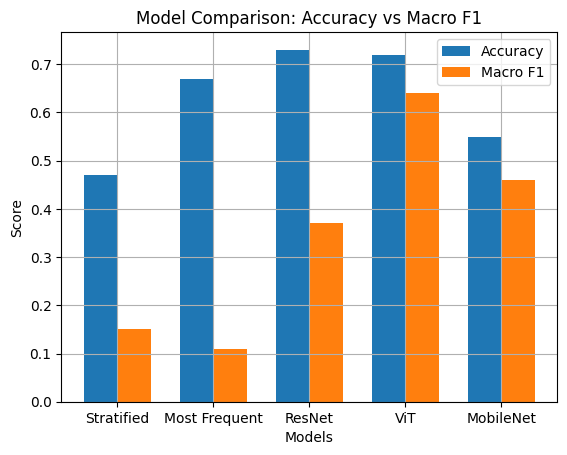

In [81]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(models))

plt.figure()

width = 0.35

plt.bar(x - width/2, accuracy, width, label='Accuracy')
plt.bar(x + width/2, macro_f1, width, label='Macro F1')

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Comparison: Accuracy vs Macro F1")

plt.legend()
plt.grid()

plt.savefig("C:/Users/sirij/Downloads/comparison_graph.png")

plt.show()

In [74]:
!pip install seaborn

     ------------------------------------ 294.9/294.9 kB 701.2 kB/s eta 0:00:00



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


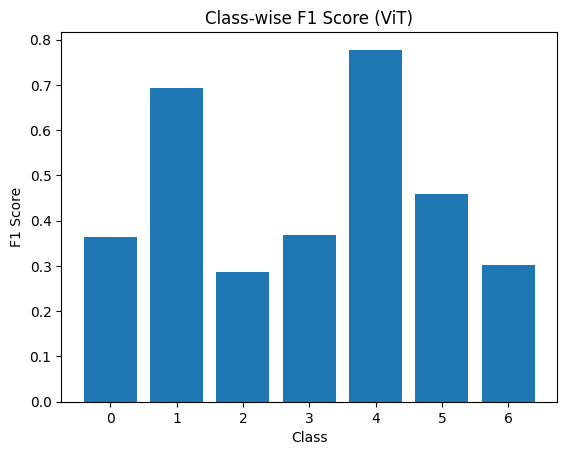

In [75]:
from sklearn.metrics import classification_report
import seaborn as sns

report = classification_report(true, preds, output_dict=True)

f1_scores = [report[str(i)]['f1-score'] for i in range(7)]

plt.figure()
plt.bar(range(7), f1_scores)

plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("Class-wise F1 Score (ViT)")

plt.savefig("classwise_f1.png")
plt.show()